In [22]:
!pip install numpy matplotlib seaborn pandas


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [23]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [24]:
df = pd.read_csv('placement.csv')
df.head()

,cgpa,resume_score,placed
0,8.14,6.52,1
1,6.17,5.17,0
2,8.27,8.86,1
3,6.88,7.27,1
4,7.52,7.30,1


In [25]:
df.shape

(100, 3)

In [26]:
df.columns

Index(['cgpa', 'resume_score', 'placed'], dtype='str')

<Axes: xlabel='cgpa', ylabel='resume_score'>

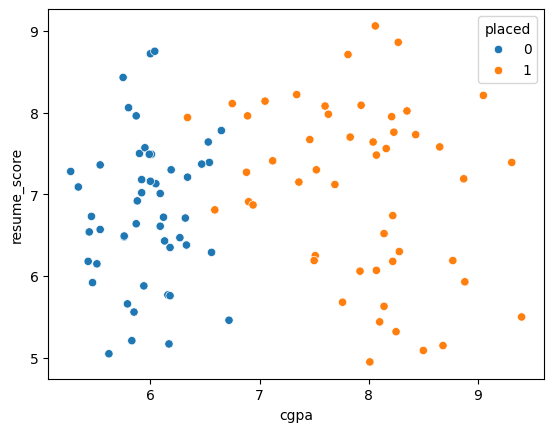

In [27]:
sns.scatterplot(x=df['cgpa'],y=df['resume_score'],hue=df['placed'])

In [28]:
X = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [29]:
!pip install scikit-learn


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [30]:
from sklearn.linear_model import Perceptron
p = Perceptron()

In [31]:
p.fit(X,y)

,"penalty penalty: {'l2','l1','elasticnet'}, default=NoneThe penalty (aka regularization term) to be used.",None
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term if regularization isused.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with `0 <= l1_ratio <= 1`.`l1_ratio=0` corresponds to L2 penalty, `l1_ratio=1` to L1.Only used if `penalty='elasticnet'`... versionadded:: 0.24",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, the iterations will stopwhen (loss > previous_loss - tol)... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.",0
,"eta0 eta0: float, default=1Constant by which the updates are multiplied.",1.0
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"random_state random_state: int, RandomState instance or None, default=0Used to shuffle the training data, when ``shuffle`` is set to``True``. Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary `.",0


In [32]:
p.coef_

array([[ 40.26, -36.  ]])

In [33]:
p.intercept_

array([-25.])

In [34]:
!pip install mlxtend


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [35]:
from mlxtend.plotting import plot_decision_regions

c:\Users\Nxtwave\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but Perceptron was fitted with feature names
  warnings.warn(


<Axes: >

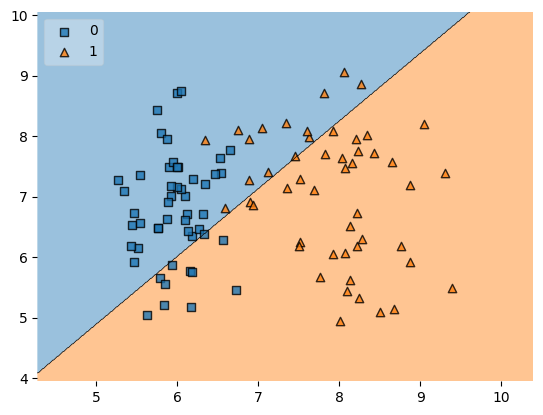

In [36]:
plot_decision_regions(X.values,y.values,clf=p,legend=2)

In [41]:
!pip install scikit-learn


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [62]:
from sklearn.datasets import make_classification
import numpy as np
import matplotlib.pyplot as plt
X, y = make_classification(n_samples=100, n_features=2, n_informative=1,n_redundant=0,
                           n_classes=2, n_clusters_per_class=1, random_state=41,hypercube=False,class_sep=10)

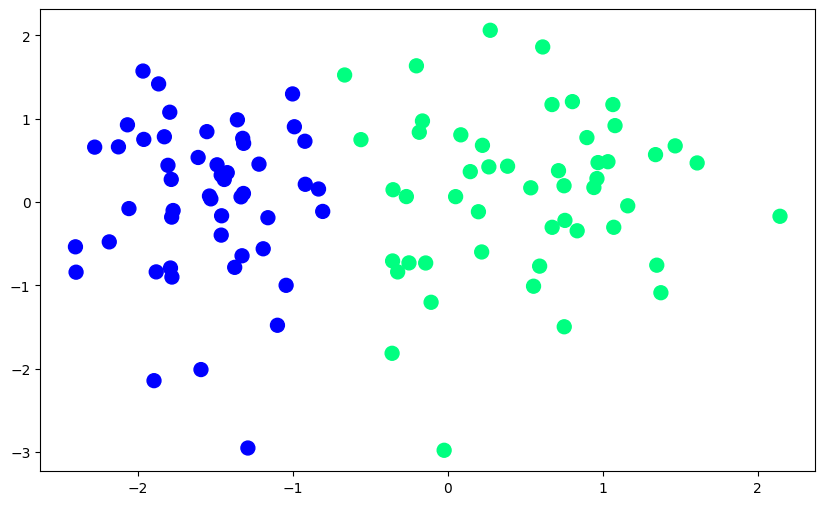

In [63]:
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)

In [64]:
def step(z):
    return 1 if z>0 else 0

In [65]:
def perceptron(X,y):
    X = np.insert(X,0,1,axis=1)
    weights = np.ones(X.shape[1])
    lr = 0.1
    for i in range(100):
        j = np.random.randint(0,100)
        y_hat = step(np.dot(X[j],weights))
        w = weights + lr*(y[j]-y_hat)*X[j]
    return weights[0],weights[1:]    

In [69]:
intercept,coef = perceptron(X,y)

In [70]:
print(intercept,coef)

1.0 [1. 1.]


In [71]:
m = -(coef[0]/coef[1])
b = -(intercept/coef[1])

In [72]:
_input = np.linspace(-3,3,100)
_output = m*_input + b

(-3.0, 2.0)

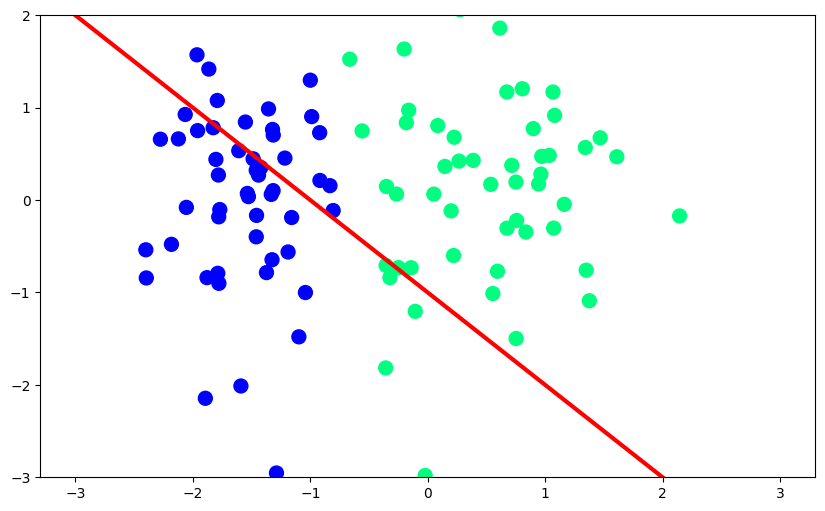

In [73]:
plt.figure(figsize=(10,6))
plt.plot(_input,_output,color='red',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)